In [1]:
from platform import python_version
print(python_version())

3.10.19


## Samtools and bcftools

### About BCFtools

BCFtools is a program for variant calling and manipulating files in the Variant Call Format (VCF) and its binary counterpart BCF. All commands work transparently with both VCFs and BCFs, both uncompressed and BGZF-compressed. In order to avoid tedious repetition, throughout this document we will use "VCF" and "BCF" interchangeably, unless specifically noted.

Most commands accept VCF, bgzipped VCF and BCF with filetype detected automatically even when streaming from a pipe. Indexed VCF and BCF work in all situations. Unindexed VCF and BCF and streams work in most, but not all situations. In general, whenever multiple VCFs are read simultaneously, they must be indexed and therefore also compressed.

https://samtools.github.io/bcftools/howtos/index.html

https://github.com/samtools/bcftools

## Concepts

### Small-Scale (Gene) Mutations

Gene mutations affect individual DNA nucleotides or base pairs: 

1. Substitution (Point Mutation): One base pair is replaced by another. Subtypes include:
  - Silent (Synonymous) Mutation: Changes a nucleotide, but the new codon codes for the exact same amino acid, causing no change to the final protein.
  - Missense Mutation: Changes a nucleotide so that a different amino acid is incorporated into the protein, which can alter or destroy protein function (e.g., sickle cell anemia).
  - Nonsense Mutation: Converts a regular amino acid codon into a premature stop codon, resulting in an incomplete, usually non-functional protein. 
  - SNP:
    - germline
    - somatic

2. InDel
  - Insertion: The addition of one or more extra nucleotides into the DNA sequence. 
  - Deletion: The removal of one or more nucleotides from the DNA sequence. 
3. Frameshift Mutation: Caused by insertions or deletions that are not in multiples of three, shifting the reading frame of the entire genetic message downstream and severely altering the resulting protein. 
4. Multi-Nucleotide Variants (MNV): Two or more neighboring nucleotide changes (often within 2 base pairs or the same protein codon) occurring on the same chromosomal haplotype. Causes: Can arise from independent single-nucleotide changes over time, error-prone DNA replication via polymerase zeta, or polymerase slippage at repeat junctions.

### Large-Scale (Chromosomal) Mutations

Chromosomal mutations alter the structure of a chromosome or the total number of chromosomes: 

1. Duplication: A segment of a chromosome is copied and repeated, leading to extra genetic material.
2. Inversion: A segment of a chromosome is broken off, flipped 180 degrees, and reinserted backwards.
3. Translocation: A piece of one chromosome breaks off and attaches to a completely different, non-homologous chromosome.
4. Aneuploidy (Numerical): An abnormal number of chromosomes, such as having an extra chromosome or missing one, often caused by non-disjunction during cell division. 
5. Polyploidy
5. Mismatch repair
6. Repeat expansion
7. Structural variants

### Mitochondria

1. Mitochondrial heteroplasmy is the presence of more than one type of mitochondrial DNA (mtDNA) within a single cell, tissue, or organism. Cells contain multiple mitochondria with hundreds to thousands of DNA copies; when a mutation arises in some, normal (wild-type) and mutated genomes coexist.

### **DP means depth**:

**DP means depth**: the number of sequencing reads that cover a position, also called coverage. It measures how much evidence stands behind a call.

It appears in two places with slightly different meanings:

| Field | Meaning | Example |
|---|---|---|
| `INFO/DP` | Total reads at the site, **summed over all samples** | `DP=152` (52 normal + 100 tumor) |
| `FORMAT/DP` | Reads at the site **in one sample** | NORMAL `52`, TUMOR `100` |


###  **Allelic Depth (AD)** and **VAF variant allele fraction (VAF)**

**How it relates to AD.** `AD` (allelic depth) splits the reads by allele. In the tumor above, `AD=61,39` means 61 reads carry the reference base and 39 the alternate:

```
VAF = alt reads / (ref + alt) = 39 / (61 + 39) = 0.39
```

**In VCF files** it appears either directly as `FORMAT/AF` (Mutect2 writes this) or can be computed from `FORMAT/AD`. Your script does exactly that in `vaf_from()`: it uses `AF` when present and falls back to `AD`.


`DP` is often **slightly larger** than the sum of `AD`, because DP can include reads the caller later excluded from AD, such as low base quality, ambiguous reads or reads supporting a third allele. The exact definition depends on the caller (GATK, Mutect2, DeepVariant, bcftools call each differ a little), so the header's `Description=` line is the authority.


**Why filter on it.** Low depth means low confidence:

- **Germline calls:** at DP = 5, a true heterozygote can easily show 5 ref and 0 alt reads by chance and be called homozygous reference. Common minimums are DP ≥ 10–20.

- **Somatic calls:** depth limits how low an allele fraction you can detect. At DP = 20, a variant at 5% VAF gives about 1 read, which can't be told apart from noise. At DP = 200 it gives about 10 reads. For low-purity tumors such as PDAC, where VAFs are often 5–20%, you usually need DP ≥ 100–200 in the tumor.

- **Very high DP** can also be suspicious in whole-genome data. Unusually high depth may mean a collapsed repeat or a region duplicated elsewhere in the genome, so some pipelines also set an upper limit (e.g. more than 2–3× the mean).


So your `include="FMT/DP>=20"` keeps records where at least one sample has 20 or more reads. `MIN(FMT/DP)>=20` would require every sample to have at least 20.


### **Don't confuse VAF with Population Allele Frequency (PAF)** 

`INFO/AF` in gnomAD or 1000 Genomes files is how common an allele is **across people**, e.g. 0.66 for TP53 P72R. VAF is about **one sample's reads**.

**What VAF tells you:**

| Context | Expected VAF | Why |
|---|---|---|
| Germline heterozygous | ~0.5 | one of two copies carries it |
| Germline homozygous | ~1.0 | both copies |
| Somatic, pure tumor, heterozygous | ~0.5 | as in germline |
| Somatic in a real tumor | often 0.05–0.4 | normal cells in the sample dilute it |
| Subclonal mutation | lower still | only some tumor cells carry it |
| Mitochondrial heteroplasmy | any value 0–1 | cells carry hundreds of mtDNA copies (m.3243A>G at 0.30 vs 0.75 in the example) |
| Clonal hematopoiesis (CHIP) in blood | often 0.02–0.10 | a small clone among normal blood cells |


### **For somatic mutations**, VAF depends on tumor purity, copy number and clonality. 

For a clonal mutation:

```
expected VAF = (purity × mutated copies) / (purity × tumor CN + (1 − purity) × 2)
```

Some worked examples:

- A heterozygous mutation in a diploid tumor at 30% purity gives VAF ≈ 0.15. That's typical for PDAC, where the dense stroma lowers purity.

- The same mutation after loss of the other copy (LOH), e.g. TP53 with 17p loss, gives a higher VAF, often above half the purity. That's why TP53 had VAF 0.78 in the example tumor.

- KRAS mutations are often amplified in PDAC, which also raises VAF.


### This is also why the somatic filter in your script compares VAFs

- a real somatic call has tumor VAF ≥ `min_vaf` (0.05) and 
- normal VAF ≤ `max_normal_vaf` (0.02). 
- Some normal VAF is tolerated because a few tumor cells can contaminate the normal sample.


These are how a bcftools filter expression says **which part of a VCF record** a field comes from. A VCF line has two places where values live:

```
#CHROM POS       ID REF ALT QUAL FILTER INFO                  FORMAT       NORMAL           TUMOR
chr7   140753336 .  A   T   .    PASS   DP=152;SOMATIC;GENE=BRAF  GT:AD:AF:DP  0/0:52,0:0.0:52  0/1:61,39:0.39:100
                                        └──── INFO (site) ────┘  └ keys ──┘  └── one block per sample ──┘
```

- **INFO** holds values about the **site** as a whole: one value per record, e.g. total depth across all samples, gene name, SV type.

- **FORMAT + sample columns** hold values **per sample**. The `FORMAT` column lists the keys (`GT:AD:AF:DP`), and each sample column has its own values in that order.

<br>

| Notation | Means | In the example |
|---|---|---|
| `INFO/X` | the INFO field named X | `INFO/DP` = 152 (the whole site) |
| `FORMAT/X` | the per-sample field named X | `FORMAT/DP` = 52 in NORMAL, 100 in TUMOR |
| `FMT/X` | the same as `FORMAT/X`, just shorter | `FMT/DP` = 52 and 100 |
| `FMT/DP` | read depth in **each sample** | used in your filter `FMT/DP>=20` |

**Why the prefix matters.** The same name can exist in both places with different meanings. `DP` is the most common case: `INFO/DP` is the site's total depth, while `FORMAT/DP` is each sample's depth. The same goes for `AF`, which is population frequency in INFO but a sample's allele fraction in FORMAT. A bare `DP` makes bcftools guess which one you mean, and the prefix removes the ambiguity.

**How `FMT/X` behaves with several samples:**

| Expression | Keeps the record if |
|---|---|
| `FMT/DP>=20` | **any** sample has DP ≥ 20 |
| `MIN(FMT/DP)>=20` | **every** sample has DP ≥ 20 |
| `FMT/DP[1]>=20` | the 2nd sample (0-based index) has DP ≥ 20 |
| `FMT/DP[@TUMOR]>=20` | sample "TUMOR" has DP ≥ 20 (samples can be named, in recent bcftools) |
| `INFO/DP>=100 && FMT/AF[1]>=0.05` | the combined site depth is ≥ 100 and the 2nd sample's AF is ≥ 0.05 |

**Where the definitions come from.** Every tag must be declared in the header:

```
##INFO=<ID=DP,Number=1,Type=Integer,Description="Total depth">
##FORMAT=<ID=DP,Number=1,Type=Integer,Description="Read depth">
```

If the line for a tag isn't there, bcftools stops with `the tag "DP" is not defined`, which is the error you hit with the CNV file. That's why the script's `missing_filter_tags()` scans your expression for `INFO/X`, `FMT/X` and `FORMAT/X` (the `X` stands for any tag name). It then checks each one against the `##INFO` or `##FORMAT` lines of that particular file before running the filter.

One limitation: `missing_filter_tags()` only recognizes **prefixed** tags. A bare tag like `DP>=20` isn't checked, so a file without it would still fail. Always writing the prefix avoids that.

### **CSI stands for Coordinate-Sorted Index.**

It's an index file (`.csi`) that sits next to a compressed VCF, BCF or BAM and records where in the file each genomic region starts. With it, a tool can jump directly to `chr17:7,661,779-7,687,538` instead of reading the whole file from the start.

In your pipeline:
```
normalized.bcf        ← the data
normalized.bcf.csi    ← the index that `bcftools index` creates
```

**How it works.** The genome is divided into nested bins, from large regions down to small windows of 16 kb by default. For each bin, the index stores the byte offsets in the compressed file where records in that bin begin. A region query looks up the matching bins and jumps to those offsets.

**CSI vs TBI.** TBI is the older tabix index, and both do the same job:

| | `.tbi` (tabix) | `.csi` |
|---|---|---|
| Works with | bgzipped VCF, BED, GFF | bgzipped VCF, BCF, BAM, BED… |
| Maximum chromosome length | 2²⁹ bp ≈ 512 Mb | much larger (the bin size is configurable) |
| Used for BCF | no | yes, BCF must use CSI |
| bcftools default | with `index -t` | yes, the default for `bcftools index` |

The chromosome-length limit is the main reason CSI exists. Human chromosomes are all under 512 Mb, so TBI works fine for human VCFs. Some plant and amphibian genomes (wheat, axolotl) have longer chromosomes and need CSI.

**Requirements.** The file must be:
1. **bgzip-compressed** (block gzip, not regular `gzip`) or BCF, and
2. **sorted by position**, otherwise indexing fails with an "unsorted positions" error. `bcftools sort` fixes that.

```bash
bcftools index file.vcf.gz          # creates file.vcf.gz.csi
bcftools index -t file.vcf.gz       # creates file.vcf.gz.tbi instead
bcftools index -f file.bcf          # -f overwrites an existing index
bcftools index -n file.vcf.gz       # prints the number of records (read from the index)
```

For your human data, either index type works. Some older tools, such as older GATK versions and IGV, accept only `.tbi` for VCF.gz. If one of them complains, create a `.tbi` with `bcftools index -t`.

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

from scipy.stats import spearmanr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/mutation_analysis")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, str(ROOT_SRC))

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir

root_figure = create_dir(ROOT0, "pictures")
root_results = create_dir(ROOT0, "results")
root_data = create_dir(ROOT0, "data")
root_vcf = create_dir(root_data, "vcf")

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/mutation_analysis
ROOT_SRC added: /home/flavio/uv/mutation_analysis/src


In [3]:
[x for x in os.listdir(root_vcf) if x.endswith('.vcf')]

['10_polyploidy_genotypes.vcf',
 '09_aneuploidy_chromosome_arm.vcf',
 '07_structural_variants.vcf',
 '04_small_indels.vcf',
 '05_mismatch_repair_MSI_homopolymer.vcf',
 '08_cnv_focal_segments.vcf',
 '06_str_repeat_expansion.vcf',
 '01_snp_germline_trio.vcf',
 '03_mnv_dinucleotide.vcf',
 '02_snv_somatic_tumor_normal.vcf',
 '11_mito_heteroplasmy.vcf']

### VCF analyser

In [4]:
from libs.vcf_analyzer import *

In [5]:
PLOIDY_NAME

{0: 'missing',
 1: 'haploid',
 2: 'diploid',
 3: 'triploid',
 4: 'tetraploid',
 5: 'pentaploid',
 6: 'hexaploid'}

In [6]:
files = [x for x in os.listdir(root_vcf) if x.endswith('.vcf.gz')]
files.sort()
files

['01_snp_germline_trio.vcf.gz',
 '02_snv_somatic_tumor_normal.vcf.gz',
 '03_mnv_dinucleotide.vcf.gz',
 '04_small_indels.vcf.gz',
 '05_mismatch_repair_MSI_homopolymer.vcf.gz',
 '06_str_repeat_expansion.vcf.gz',
 '07_structural_variants.vcf.gz',
 '08_cnv_focal_segments.vcf.gz',
 '09_aneuploidy_chromosome_arm.vcf.gz',
 '10_polyploidy_genotypes.vcf.gz',
 '11_mito_heteroplasmy.vcf.gz']

In [7]:
from types import SimpleNamespace

i = 7
VCFS             = [root_vcf / files[i]]  # VCF / VCF.gz / BCF files
OUTDIR           = "vcf_analysis"
BCFTOOLS         = "bcftools"      # bcftools executable (or full path, e.g. /usr/local/bin/bcftools)
REF              = None            # indexed reference FASTA, e.g. "/data/refs/hg38.fa"
INCLUDE          = None            # bcftools filter expression, e.g. "QUAL>30 && FMT/DP>10"
REGIONS          = None            # e.g. "chr17:7661779-7687538"
PASS_ONLY        = False           # keep only FILTER=PASS (or '.') records
BASELINE_PLOIDY  = 2               # expected copy number (4 after genome doubling)
MIN_VAF          = 0.05            # minimum tumor VAF for a somatic call
MAX_NORMAL_VAF   = 0.02            # maximum normal VAF for a somatic call
THREADS          = 2
NO_PLOTS         = False

print(VCFS, VCFS[0].exists())

[PosixPath('/home/flavio/uv/mutation_analysis/data/vcf/08_cnv_focal_segments.vcf.gz')] True


### Running

```Python
def run(vcfs:list, bcftools:str, ref:Path|str|None=None, include:str|None=None,
        regions:Path|str|None=None, pass_only:bool=True, baseline_ploidy:int=2,
        min_vaf:float=0.05, max_normal_vaf:float=0.02, threads:int=2, no_plots:bool=False,
        root_results:Path|str|None=None, root_figure:Path|str|None=None, 
        figname_classes:str|None=None, figname_cn:str|None=None, dpi:int=150):
```

[warn] 08_cnv_focal_segments.vcf.gz: FMT/DP not in header; skipping filter 'FMT/DP>=20' for this file


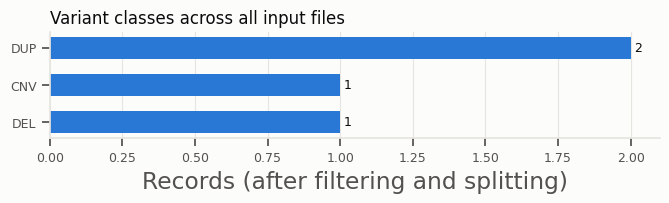

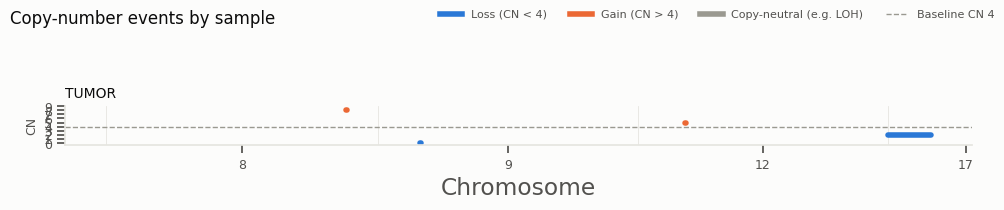

In [8]:
res = run(vcfs=VCFS, bcftools="/usr/local/bin/bcftools",
          root_results=root_results, root_figure=root_figure,
          pass_only=True, include="FMT/DP>=20", baseline_ploidy=4,
          figname_classes="variant_classes.png", figname_cn="copy_number.jpeg", dpi=150)



In [9]:
# results come back as Python objects, not just files
res[0]["summary"]                 # dict: classes, ploidy, aneuploidy, somatic counts

{'file': '/home/flavio/uv/mutation_analysis/data/vcf/08_cnv_focal_segments.vcf.gz',
 'fileformat': 'VCFv4.4',
 'samples': ['TUMOR'],
 'tumor_normal': None,
 'records_after_filters': 4,
 'variant_classes': {'DUP': 2, 'DEL': 1, 'CNV': 1},
 'event_scales': {'FOCAL_SV': 3, 'ARM_LEVEL': 1},
 'msi_slippage_indels': 0,
 'repeat_expansions': 0,
 'ts_tv': None,
 'bcftools_SN': {'samples': 1,
  'records': 4,
  'no-ALTs': 0,
  'SNPs': 0,
  'MNPs': 0,
  'indels': 0,
  'others': 4,
  'multiallelic sites': 0,
  'multiallelic SNP sites': 0},
 'dominant_ploidy': {},
 'aneuploid_chromosomes': [],
 'arm_level_events': ['TUMOR:chr17:ARM_LEVEL_LOSS'],
 'somatic_calls': None}

In [10]:
for key, val in res[0].items():
    print(key)

summary
sites
cn
contigs


`res[0]["sites"]` is a pandas DataFrame, the same table that is saved as `records.tsv`, for the **first VCF in your `vcfs` list**. Running it on the example files gives this for `01_snp_germline_trio`:

```
 VID CHROM       POS        ID REF ALT QUAL FILTER GENE CLASS  SIZE SCALE REPEAT
   0 chr17   7676154 rs1042522   G   C   60   PASS TP53   SNV     1 SMALL
   1  chr7 140753329         .   A   G   45   PASS BRAF   SNV     1 SMALL
   2 chr12  25245345         .   C   T   50   PASS KRAS   SNV     1 SMALL
```

For a CNV file such as `08_cnv_focal_segments` it has more columns:

```
 VID CHROM       POS          ID REF   ALT       END SVTYPE    SVLEN   GENE CLASS     SIZE     SCALE
   0  chr8 127700000     cnv_MYC   N <DUP> 127750000    DUP    50000    MYC   DUP    50000  FOCAL_SV
   1  chr9  21960000  cnv_CDKN2A   N <DEL>  22000000    DEL   -40000 CDKN2A   DEL    40000  FOCAL_SV
   2 chr12  25200000    cnv_KRAS   N <DUP>  25260000    DUP    60000   KRAS   DUP    60000  FOCAL_SV
   3 chr17         1 cnv_17p_LOH   N <CNV>  22700000    CNV 22700000      .   CNV 22700000 ARM_LEVEL
```

**What the columns mean:**
- **`VID`**: the record's row number. It links to `genotypes.tsv`, which has one row per record and sample.
- **`CHROM` … `FILTER`**: copied from the VCF, after multi-allelic sites were split and your filters applied.
- **`END`, `SVTYPE`, `SVLEN`, `GENE`, `RU`, `SOMATIC`**: these INFO fields appear only if the VCF's header defines them.
- **`CLASS`, `SIZE`, `SCALE`, `REPEAT`**: computed by the script. `REPEAT` is empty unless the record is an MSI slippage indel or a repeat expansion.

Each item in `res` holds one VCF's results, in the order of your `vcfs` list. To select a table by file name instead of by position:

```python
by_name = {Path(r["summary"]["file"]).name: r for r in res}
by_name["08_cnv_focal_segments.vcf.gz"]["sites"]
```

In [11]:
dfr = res[0]["sites"]
print(dfr.shape)
dfr

(4, 16)


,VID,CHROM,POS,ID,REF,ALT,QUAL,FILTER,END,SVTYPE,SVLEN,GENE,CLASS,SIZE,SCALE,REPEAT
0,0,chr8,127700000,cnv_MYC,N,<DUP>,.,PASS,127750000,DUP,50000,MYC,DUP,50000,FOCAL_SV,
1,1,chr9,21960000,cnv_CDKN2A,N,<DEL>,.,PASS,22000000,DEL,-40000,CDKN2A,DEL,40000,FOCAL_SV,
2,2,chr12,25200000,cnv_KRAS,N,<DUP>,.,PASS,25260000,DUP,60000,KRAS,DUP,60000,FOCAL_SV,
3,3,chr17,1,cnv_17p_LOH,N,<CNV>,.,PASS,22700000,CNV,22700000,.,CNV,22700000,ARM_LEVEL,


In [22]:
VCFS

[PosixPath('/home/flavio/uv/mutation_analysis/data/vcf/08_cnv_focal_segments.vcf.gz')]

In [24]:
fname = str(VCFS[0]).split('/')[-1]
fname = fname.split('.')[0]
fname

'08_cnv_focal_segments'

In [25]:
fname2 = root_results / fname / "records.tsv"
df_rec = pd.read_csv(fname2, sep="\t")

df_rec

,VID,CHROM,POS,ID,REF,ALT,QUAL,FILTER,END,SVTYPE,SVLEN,GENE,CLASS,SIZE,SCALE,REPEAT
0,0,chr8,127700000,cnv_MYC,N,<DUP>,.,PASS,127750000,DUP,50000,MYC,DUP,50000,FOCAL_SV,NaN
1,1,chr9,21960000,cnv_CDKN2A,N,<DEL>,.,PASS,22000000,DEL,-40000,CDKN2A,DEL,40000,FOCAL_SV,NaN
2,2,chr12,25200000,cnv_KRAS,N,<DUP>,.,PASS,25260000,DUP,60000,KRAS,DUP,60000,FOCAL_SV,NaN
3,3,chr17,1,cnv_17p_LOH,N,<CNV>,.,PASS,22700000,CNV,22700000,.,CNV,22700000,ARM_LEVEL,NaN


### **SNV (single-nucleotide variant)**

**SNV (single-nucleotide variant)** means one base is replaced by another, with REF and ALT each one base long:

```
REF  A   →   ALT  T        BRAF c.1799T>A, p.V600E  (chr7:140753336 A>T)
```

<br>

- **SNV vs SNP:** 
  - **SNV** says nothing about how common the change is. 
  - **SNP** (single-nucleotide polymorphism) traditionally means a germline SNV that is common in the population, often defined as allele frequency ≥ 1%. 

- So the 
  - TP53 P72R variant rs1042522 is a SNP, 
  - while the somatic BRAF V600E in a tumor is an SNV, not a SNP. 
  - In practice people use the two terms loosely.

- **Transitions and transversions:** 
  - SNVs are either 
    - transitions (purine↔purine A↔G, or pyrimidine↔pyrimidine C↔T) or 
    - transversions (purine↔pyrimidine). 
    - The `ts_tv` value in your summary is the ratio between them. 
    - In human germline calls it is about 2.0–2.1 genome-wide and about 3.0 in exomes. 
    - A much lower value suggests many false-positive calls.

<br>

### **MNV (multi-nucleotide variant)** 

**MNV (multi-nucleotide variant)** means two or more **adjacent** bases change together on the **same chromosome copy**. REF and ALT have the same length, more than one base:

```
REF  CA  →   ALT  TT       BRAF c.1798_1799GT>AA, p.V600K
```

- **Why MNVs matter:** 
  - reading the two changes separately gives the wrong protein effect. 
  - Here, calling them as two SNVs (C>T and A>T) would be annotated as two unrelated amino-acid changes. 
  - Taken together, they form the single codon change V600K, which is clinically distinct from V600E.

- **Names by length:** 
  - a two-base MNV is a DNV (dinucleotide variant), three bases a TNV, and so on.

- **Where they come from:**
  - UV damage gives the tandem CC>TT signature in melanoma (COSMIC signature DBS1).
  - Tobacco smoke gives CC>AA (DBS2).
  - POLE/POLD1 proofreading defects and mismatch-repair defects also produce them.
  - Some are simply two neighbouring SNPs inherited together.

- **Caller caveat:** 
  - many variant callers, including GATK Mutect2 by default, write an MNV as separate adjacent SNV records. 
  - Re-merge them before annotating, e.g. with `bcftools norm -m +any` or Mutect2's MNP options. 
  - The phase information (`PS` or `|` genotypes) tells you whether the SNVs are on the same copy.

**How your script labels them?** 

- Any record whose REF and ALT have equal length is `SNV` if the length is 1 and `MNV` if longer. 
- The script doesn't check whether every base actually differs,
  - so a record like `CAG → CTG`, where only the middle base changes but the caller padded it with flanking bases, is labelled `MNV`. 
- Running with `ref=` (so `bcftools norm -f` normalizes each record against the reference) 
  - doesn't remove shared flanking bases from equal-length records. 
  - to catch these cases you'd compare REF and ALT base by base.


### **SCALE** sorts each variant by how much of the genome it affects

`SCALE` is a column in `records.tsv`. 

It sorts each variant by how much of the genome it affects, using the variant's length compared with its chromosome's length (from the `##contig` lines in the VCF header). 

The script checks the rules from the top down, and the first one that matches wins:

| SCALE | Rule in the code | Size range | What it usually means | Examples from the test files |
|---|---|---|---|---|
| `SMALL` | SNV or MNV, or an indel shorter than 50 bp | 1–49 bp | Point mutations and small insertions/deletions | BRAF V600E, EGFR exon 19 deletion (15 bp), TGFBR2 −1 A |
| `FOCAL_SV` | 50 bp up to 1 Mb | 50 bp – 1 Mb | Structural variants and focal copy-number changes covering a gene or a few genes | CDKN2A homozygous deletion (40 kb), MYC amplification (50 kb), ERBB2 tandem duplication (30 kb) |
| `LARGE` | 1 Mb up to 10 Mb, and under 25% of the chromosome | 1–10 Mb | Large segmental events spanning many genes, but smaller than a chromosome arm | none in the examples (a 5 Mb deletion would be one) |
| `ARM_LEVEL` | ≥ 10 Mb, **or** ≥ 25% of the chromosome | ≥ 10 Mb | Events roughly the size of a chromosome arm | 8q gain, 9p loss, 18q loss, 17p copy-neutral LOH |
| `WHOLE_CHROMOSOME` | ≥ 90% of the chromosome | whole chromosome | Whole-chromosome aneuploidy | trisomy 21, 45,X |
| `.` | Repeat alleles (`<STR..>`), reference blocks (`<*>`), or no size available | — | Size isn't meaningful for these records | HTT `<STR40>`, the chrY reference block |

A few details about these cutoffs:

- **50 bp** is the usual boundary between an indel and a structural variant. Most SV callers and the GIAB benchmark sets use it.

- **The arm-level rule is only a proxy.** 
  - The script doesn't know where centromeres are, so 
  - "≥ 25% of the chromosome" stands in for "about arm-sized." 
  - The alternative "≥ 10 Mb" rule means a 12 Mb event on chr1 (about 5% of it) is still labelled `ARM_LEVEL`. 
  - For exact arm calls you would compare breakpoints with a centromere/cytoband file.

- **Size is measured differently by variant type.** 
  - For symbolic alleles it comes  
    - from `SVLEN`, or 
    - from `END − POS + 1` when `SVLEN` is absent. 
    - For sequence alleles it's the length difference between ALT and REF.


### Call

A second, separate classification appears in `aneuploidy.tsv` (column `call`). It works per sample and per chromosome and adds up **all** gain or loss segments on that chromosome, so several smaller segments can together amount to an arm-level or whole-chromosome call:

| call | Rule (fraction of the chromosome covered) |
|---|---|
| `WHOLE_CHROMOSOME_GAIN` / `_LOSS` | gained (or lost) ≥ 90% |
| `ARM_LEVEL_GAIN` / `_LOSS` | gained (or lost) ≥ 25% |
| `FOCAL_ONLY` | the chromosome has copy-number events, but they cover under 25% |

Gains include `GAIN`, `AMP` and `GAIN_LOH`, and losses include `LOSS` and `HOMDEL`. Copy-neutral LOH counts as neither, because the copy number doesn't change.

In [12]:
dfcn = res[0]["cn"]
dfcn

,SAMPLE,CHROM,POS,END,SIZE,SCALE,CN,CN_STATE,MCN,GENE
2,TUMOR,chr12,25200000,25260000,60000,FOCAL_SV,5,GAIN,1,KRAS
3,TUMOR,chr17,1,22700000,22700000,ARM_LEVEL,2,LOSS,0,.
0,TUMOR,chr8,127700000,127750000,50000,FOCAL_SV,8,GAIN_LOH,0,MYC
1,TUMOR,chr9,21960000,22000000,40000,FOCAL_SV,0,HOMDEL,0,CDKN2A


In [13]:
dfctg = res[0]["contigs"]
print(type(dfctg))
dfctg

<class 'dict'>


{'chr8': 145138636, 'chr9': 138394717, 'chr12': 133275309, 'chr17': 83257441}

In [14]:
for r in res:
    print(r, '\n')

{'summary': {'file': '/home/flavio/uv/mutation_analysis/data/vcf/08_cnv_focal_segments.vcf.gz', 'fileformat': 'VCFv4.4', 'samples': ['TUMOR'], 'tumor_normal': None, 'records_after_filters': 4, 'variant_classes': {'DUP': 2, 'DEL': 1, 'CNV': 1}, 'event_scales': {'FOCAL_SV': 3, 'ARM_LEVEL': 1}, 'msi_slippage_indels': 0, 'repeat_expansions': 0, 'ts_tv': None, 'bcftools_SN': {'samples': 1, 'records': 4, 'no-ALTs': 0, 'SNPs': 0, 'MNPs': 0, 'indels': 0, 'others': 4, 'multiallelic sites': 0, 'multiallelic SNP sites': 0}, 'dominant_ploidy': {}, 'aneuploid_chromosomes': [], 'arm_level_events': ['TUMOR:chr17:ARM_LEVEL_LOSS'], 'somatic_calls': None}, 'sites':    VID  CHROM        POS           ID REF    ALT QUAL FILTER        END SVTYPE     SVLEN    GENE  \
0    0   chr8  127700000      cnv_MYC   N  <DUP>    .   PASS  127750000    DUP     50000     MYC   
1    1   chr9   21960000   cnv_CDKN2A   N  <DEL>    .   PASS   22000000    DEL    -40000  CDKN2A   
2    2  chr12   25200000     cnv_KRAS   N  <

In [19]:
counts = pd.concat([r["sites"]["CLASS"] for r in res if not r["sites"].empty]).value_counts()
counts

CLASS
DUP    2
DEL    1
CNV    1
Name: count, dtype: int64

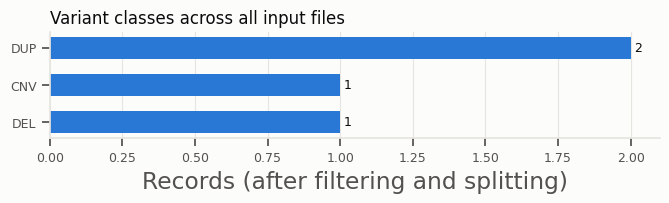

In [16]:
dpi=150

plot_classes(res, root_figure=root_figure, figname=None, dpi=dpi)

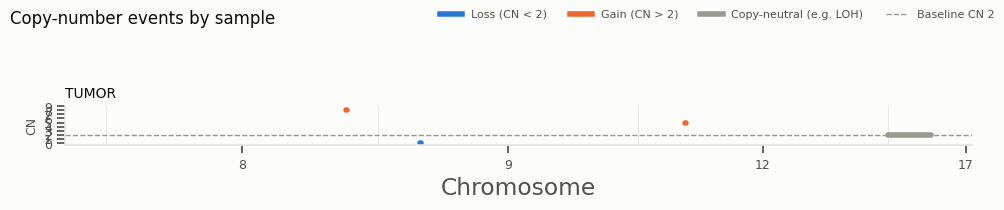

In [17]:
plot_copy_number(results=res, base=BASELINE_PLOIDY, root_figure=root_figure, figname=None, dpi=dpi)

The VCF specification (versions 4.2–4.5) allows five kinds of ALT value. Here they are, with how your script's `classify()` labels each one:

| Kind | ALT looks like | Meaning | `CLASS` in the script |
|---|---|---|---|
| **Sequence allele** | `T`, `TT`, `CTCTG`, `A` (bases A/C/G/T/N) | The actual replacement bases | `SNV`, `MNV`, `INS`, `DEL` or `COMPLEX` (depends on REF/ALT lengths) |
| **No alternate** | `.` | No variant at this site (only the reference was seen) | `NO_ALT` |
| **Spanning deletion** | `*` | This allele is removed by an overlapping deletion called at an upstream position | `NO_ALT` |
| **Symbolic allele** | `<DEL>`, `<DUP>`, ... (see the next table) | A structural or copy-number event too large, or not resolved enough, to spell out as bases | the tag (see the next table) |
| **Breakend** | `G]chr17:198982]`, `]chr13:123456]T`, `C[chr2:321682[`, `[chr17:198983[A` | One side of a novel junction: translocation, inversion or fusion | `BND` |
| **Single breakend** | `G.` or `.G` | One side of a junction whose partner couldn't be placed | ⚠️ currently mislabelled `INS` or `DEL` (see the note at the end) |

**Symbolic alleles.** The first group is defined by the VCF specification, the rest are common tool-specific tags:

| Symbolic ALT | Meaning | `CLASS` |
|---|---|---|
| `<DEL>` | Deletion | `DEL` |
| `<INS>` | Insertion whose sequence isn't spelled out | `INS` |
| `<DUP>` | Duplication | `DUP` |
| `<DUP:TANDEM>` | Tandem duplication | `DUP` |
| `<INV>` | Inversion | `INV` |
| `<CNV>` | Copy-number variable region (the copy number is in `FORMAT/CN`) | `CNV` |
| `<DEL:ME>`, `<DEL:ME:ALU>`, `<DEL:ME:L1>` | Deletion of a mobile element | `DEL` |
| `<INS:ME>`, `<INS:ME:ALU>`, `<INS:ME:LINE1>`, `<INS:ME:SVA>` | Mobile-element insertion | `INS` |
| `<CNV:TR>` | Tandem-repeat copy-number change (added in VCF 4.4) | `CNV` |
| `<*>` | "Any other allele" in gVCFs and reference blocks (bcftools) | `REF_BLOCK` |
| `<NON_REF>` | GATK's name for `<*>` in its HaplotypeCaller gVCFs | `REF_BLOCK` |
| `<STR40>`, `<STR19>` | ExpansionHunter/STR callers: allele with N repeat units | `STR` |
| `<BND>` | Some callers write this instead of the bracket notation | `BND` |

<br>

**The four breakend forms.** Take `t` as the REF base and `p` as the partner position:

| ALT | Joined as |
|---|---|
| `t[p[` | t, then the sequence starting at p, extending right |
| `t]p]` | t, then the reverse complement of the sequence ending at p (extending left) |
| `]p]t` | the sequence ending at p, then t |
| `[p[t` | the reverse complement of the sequence starting at p, then t |

A breakend can also carry inserted bases at the junction, e.g. `tAAC[p[`.

<br>

**The sequence classes, which depend on the REF/ALT lengths:**

| REF → ALT | `CLASS` |
|---|---|
| `A → T` | `SNV` |
| `CA → TT` | `MNV` |
| `C → CTCTG` | `INS` |
| `AGGAATTAAGAGAAGC → A` | `DEL` |
| `ACG → T` (lengths differ, no shared first base) | `COMPLEX` |

⚠️ One gap turned up while going through this list: single breakends (`G.` / `.G`) are classified as insertions or deletions, because `G.` starts with the REF base `G`. Callers such as GRIDSS and Manta emit these. The fix is a one-line check before the length tests in `classify()`:

```python
    if alt.startswith(".") or alt.endswith("."):      # single breakend: G.  or  .G
        return "BND"
```

Put it right after the `BREAKEND.search(alt)` check.